### HW 7 

0) Package Loadings

In [ ]:
#%pip install scikit-learn-intelex
#%pip install shap
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import time
import pandas as pd
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score,GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
import shap

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


1) Loading the data and performing preprocessing steps

In [55]:
data = pd.read_csv('HW07_data_s.csv')
X = data.drop('Y', axis=1)
y = data['Y']
print(X.shape)
print(y.value_counts(normalize=True))

# Y values are heavily imbalanced, thus will need to strafiy the data when splitting to ensure that the distribution of classes is maintained in both the training and testing sets.
# Will apply stratification to the train_test_split function to ensure that the class distribution is preserved in both the training and testing sets.
# Need to consider scaling the features as well, especially for algorithms that are sensitive to feature scales (e.g., Gradient Boosting). Will use StandardScaler to standardize the features before training the models.
# I want to analyze the feature space, im concerned that some features may not contribute well to the feature space
# So thinking shap analysis or other statistical techniques to understand. RSS graphs?
X_dev, X_test, y_dev, y_test = train_test_split(X, y,stratify=y, test_size=0.30, random_state=42)
#scaler = StandardScaler()
#_dev_scaled = scaler.fit_transform(X_dev)
#X_test_scaled = scaler.transform(X_test)

y_test.value_counts(normalize=True)
#print(X_dev_scaled.shape)

(284807, 30)
Y
0    0.998273
1    0.001727
Name: proportion, dtype: float64


Y
0    0.998268
1    0.001732
Name: proportion, dtype: float64

In [63]:
### Declaring the stratified k-fold cross validation strategy to be used for all models
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

### Decision Tree Classifier.
The process in this section is to deal with the heavily imbalanced dataset that is shown by this development set
1) When fitting this model onto the development set we will balance class_weight since of the high '0' class to '1' class
2) We will CV the Decision Tree under a 10-fold StratifiedKFold to analyze F1_macro performance.
3) Once we CV and compare scores we will then grid search optimal hyper params and train the best model for downstream analysis

In [ ]:
#Defining the baseline decision tree
tree = DecisionTreeClassifier(random_state=42)


score = cross_val_score(tree, X_dev, y_dev, cv=kfold, scoring='f1_macro', n_jobs=-1).mean()
print("Baseline CV F1 score:", score)


Baseline CV F1 score: 0.8686723600091888


In [57]:
#Defining the tree
tree2 = DecisionTreeClassifier(random_state=42,class_weight='balanced')

score = cross_val_score(tree2, X_dev, y_dev, cv=kfold, scoring='f1_macro', n_jobs=-1).mean()
print("Balanced CV F1 score:", score)



Balanced CV F1 score: 0.8564071833309581


In [78]:
tree = DecisionTreeClassifier(random_state=42)
param_grid = {
  'max_depth': [3, 5, 10, None],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 5, 10]
}
# Run GridSearchCV to find the best parameters based on f1 score as it is a better average metric for datasets

grid = GridSearchCV(tree, param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1)
grid.fit(X_dev, y_dev)

best_params_dt = grid.best_params_
print(f"Best Parameters: {best_params_dt}")


Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


Time taken to fit the tree: 3.3608 seconds


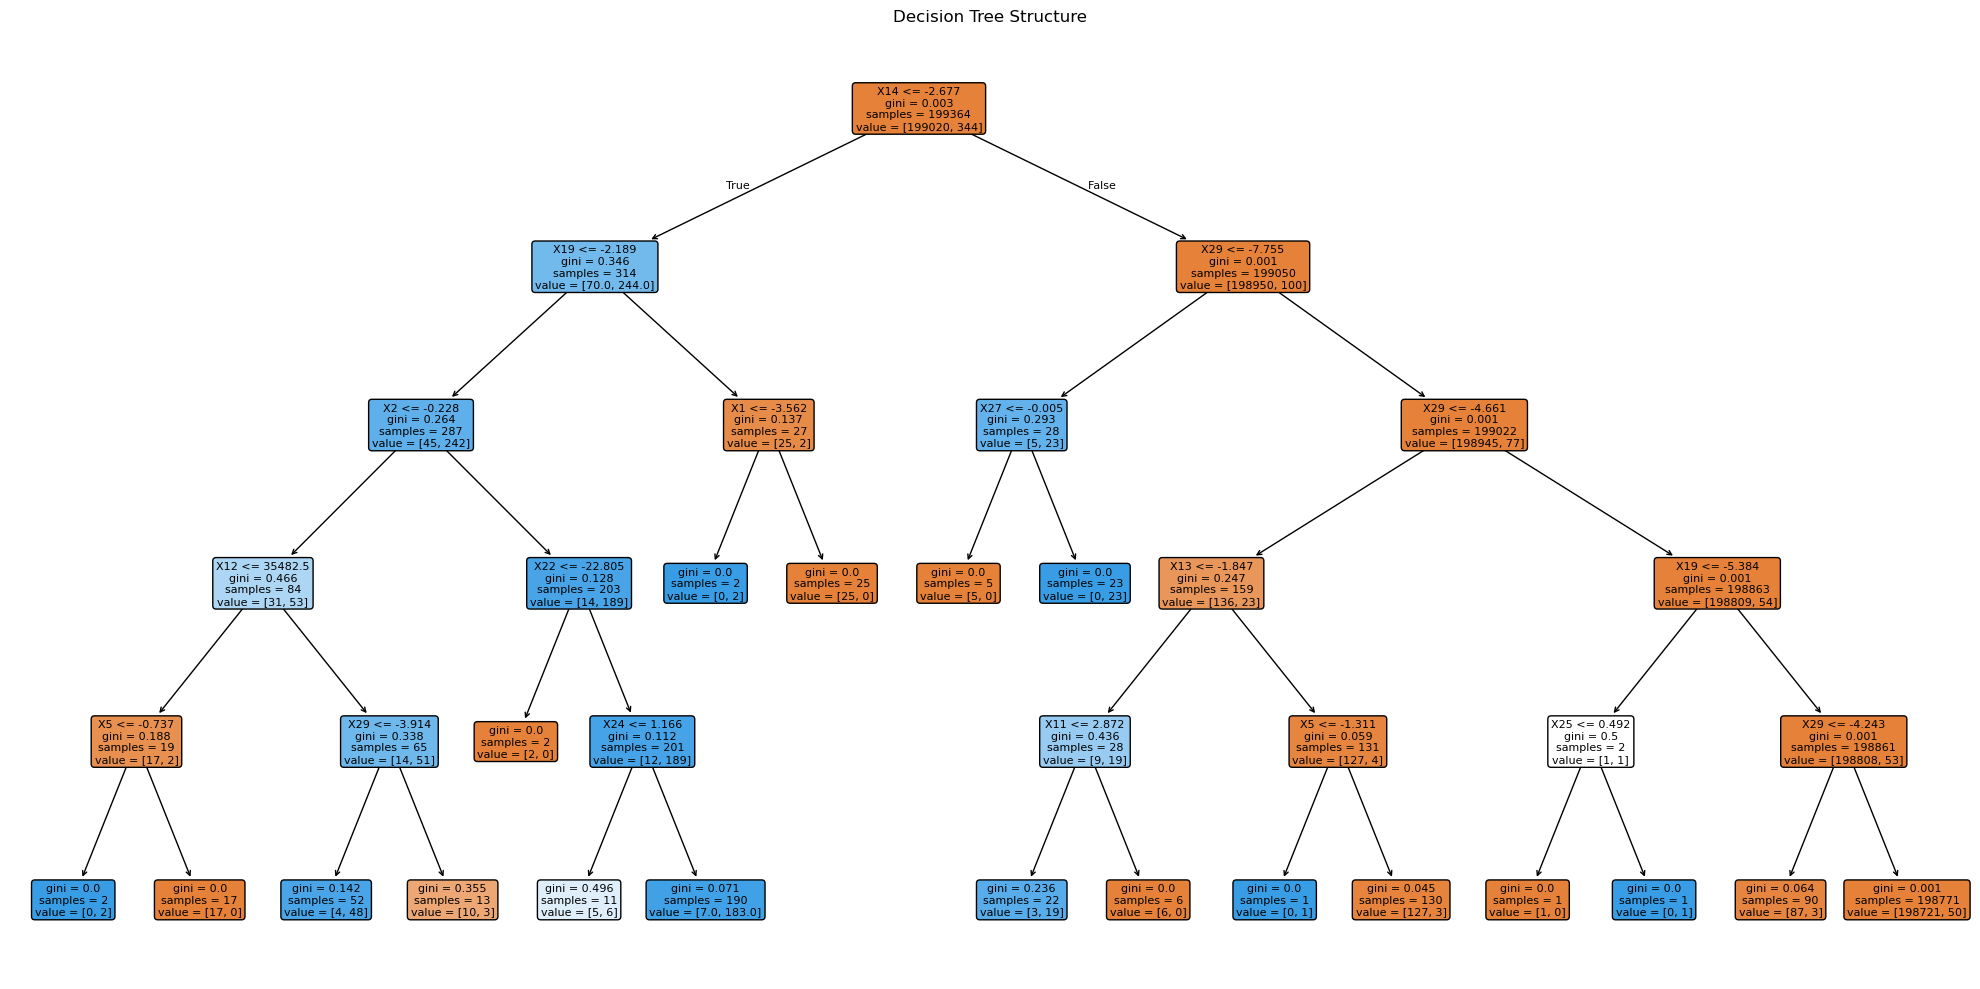

In [79]:
# Visualize best tree structure

dt_best = DecisionTreeClassifier(random_state=42, **best_params_dt)
start_time = time.time() 
dt_best.fit(X_dev, y_dev)
end_time = time.time()
print(f"Time taken to fit the tree: {end_time - start_time:.4f} seconds")
plt.figure(figsize=(20, 10))
plot_tree(dt_best, filled=True, feature_names=X_dev.columns,  rounded=True, fontsize=8)
plt.title("Decision Tree Structure")
plt.tight_layout()
plt.show()

### Random Forest Classifier
1) Compare the class weights: None, balanced, and balanced_subsample
2) Optimize Hyper Parameters
3) Train best model for down stream analysis

In [67]:
#Defining the tree
treeRf1 = RandomForestClassifier(random_state=42,class_weight=None,n_jobs=-1)

score = cross_val_score(treeRf1, X_dev, y_dev, cv=kfold, scoring='f1_macro', n_jobs=-1).mean()
print("Baseline RFC CV F1 score:", score)

c:\Users\tjmel\miniconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Baseline RFC CV F1 score: 0.9255359249847338


In [68]:
#Defining the tree
treeRf2 = RandomForestClassifier(random_state=42,class_weight='balanced',n_jobs=-1)

score = cross_val_score(treeRf2, X_dev, y_dev, cv=kfold, scoring='f1_macro', n_jobs=-1).mean()
print("Balanced RFC CV F1 score:", score)

Balanced RFC CV F1 score: 0.5640120079175408


In [69]:
#Defining the tree
treeRf3 = RandomForestClassifier(random_state=42,class_weight='balanced_subsample',n_jobs=-1)

score = cross_val_score(treeRf3, X_dev, y_dev, cv=kfold, scoring='f1_macro', n_jobs=-1).mean()
print("Balanced_subsample RFC CV F1 score:", score)

c:\Users\tjmel\miniconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Balanced_subsample RFC CV F1 score: 0.9226355301128594


Comparing these scores we see for all three on f1_macro scoring the Baseline RFC performs just slightly better than the balanced_subsample class weight model. Leading to the baseline RFC to perform slightly better on minority class

In [80]:
### Optimizing baseline RFC using GridSearchCV
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {
  'n_estimators': [100, 200],
  'max_depth': [5, 10, None],
  'max_features': ['sqrt', 'log2']
}
# Run GridSearchCV to find the best parameters based on f1 score as it is a better average metric for datasets

grid = GridSearchCV(rf, param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1)
grid.fit(X_dev, y_dev)

best_params_rf = grid.best_params_
print(f"Best Parameters: {best_params_rf}")

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}


In [81]:
rf_best = RandomForestClassifier(random_state=42, n_jobs=-1, **best_params_rf)
start_time = time.time() 
rf_best.fit(X_dev, y_dev)
end_time = time.time()
print(f"Time taken to fit the tree: {end_time - start_time:.4f} seconds")

Time taken to fit the tree: 1.6743 seconds


### Gradient Boosting Classifier:
1) Identify Cross Validation score
2) Then optimize it's hyper params to see if there is any improvement to be made
3) Train model for down stream use in analysis

In [82]:
#Defining the tree
treeGb = GradientBoostingClassifier(random_state=42)

score = cross_val_score(treeGb, X_dev, y_dev, cv=kfold, scoring='f1_macro', n_jobs=-1).mean()
print("Baseline GBC CV F1 score:", score)

Baseline GBC CV F1 score: 0.7600388771781132


In [83]:
gb = GradientBoostingClassifier(random_state=42)
param_grid = {
  'n_estimators': [100, 200],
  'learning_rate': [0.01, 0.1],
  'max_depth': [3, 5]
}
# Run GridSearchCV to find the best parameters based on f1 score as it is a better average metric for datasets

grid = GridSearchCV(gb, param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1)
grid.fit(X_dev, y_dev)

best_params_gb = grid.best_params_
print(f"Best Parameters: {best_params_gb}")

KeyboardInterrupt: 

In [ ]:
gb_best = GradientBoostingClassifier(random_state=42, **best_params_gb)
start_time = time.time()
gb_best.fit(X_dev, y_dev)
end_time = time.time()
print(f"Time taken to fit the tree: {end_time - start_time:.4f} seconds")

In [ ]:
results = []

for model in [dt_best, rf_best, gb_best]:
    model_name = model.__class__.__name__
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Macro)": precision_score(y_test, y_pred, average='macro'),
        "Recall (Macro)": recall_score(y_test, y_pred, average='macro'),
        "F1 Score (Macro)": f1_score(y_test, y_pred, average='macro'),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Pretty display
print(results_df.to_string(index=False))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.07      0.86      0.13       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.56     85443
weighted avg       1.00      0.98      0.99     85443

[[83549  1746]
 [   20   128]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.96      0.70      0.81       148

    accuracy                           1.00     85443
   macro avg       0.98      0.85      0.91     85443
weighted avg       1.00      1.00      1.00     85443

[[85291     4]
 [   44   104]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.73      0.16      0.27       148

    accuracy                           1.00     85443
   macro avg       0.86      0.58      0.63     85443
weighted avg

In [ ]:
for model in [dt_best, rf_best, gb_best]:
    print(f"\n=== {model.__class__.__name__} ===")
    print(classification_report(y_test, model.predict(X_test)))
    print(confusion_matrix(y_test, model.predict(X_test)))

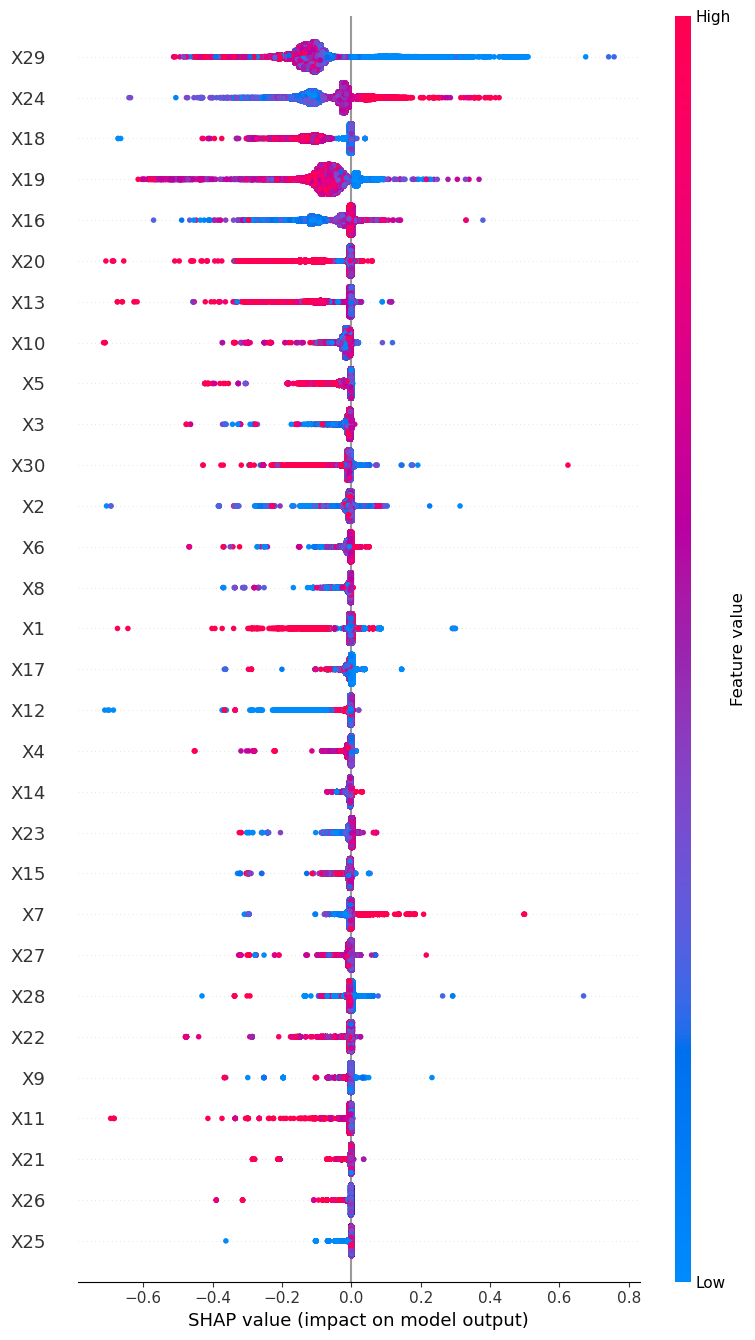

In [4]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_dev,
    feature_names=X.columns,
    max_display=30
)

In [ ]:
# class 1 importance (binary case)
sv = shap_values[:, :, 1]

importance = np.abs(sv).mean(axis=0)

feature_importance = pd.DataFrame({
    "feature": X_dev.columns,
    "importance": importance
}).sort_values("importance", ascending=False)

print(feature_importance)

   feature  importance
13     X14    0.001360
28     X29    0.001073
18     X19    0.000755
23     X24    0.000449
0       X1    0.000182
1       X2    0.000171
12     X13    0.000156
4       X5    0.000153
6       X7    0.000138
15     X16    0.000124
5       X6    0.000116
11     X12    0.000108
16     X17    0.000099
19     X20    0.000096
27     X28    0.000088
29     X30    0.000082
10     X11    0.000076
20     X21    0.000067
25     X26    0.000051
17     X18    0.000048
2       X3    0.000040
26     X27    0.000037
24     X25    0.000035
22     X23    0.000019
14     X15    0.000018
8       X9    0.000013
21     X22    0.000005
7       X8    0.000000
3       X4    0.000000
9      X10    0.000000


In [ ]:
threshold = feature_importance["importance"].mean()
selected_features = feature_importance[
    feature_importance["importance"] >= threshold
]["feature"]

In [ ]:
k = 15  # adjust
selected_features = feature_importance.head(k)["feature"]

In [ ]:
X_dev_sel = X_dev[selected_features]
X_test_sel = X_test[selected_features]
tree2 = RandomForestClassifier(random_state=42)
tree2.fit(X_dev_sel, y_dev)

pred2 = tree2.predict(X_test_sel)
acc2 = accuracy_score(y_test, pred2)

print("Reduced model accuracy:", acc2)

Reduced model accuracy: 0.9990402958697612


In [ ]:
print("Baseline:", baseline_acc)
print("Reduced:", acc2)
print("Delta:", acc2 - baseline_acc)

Baseline: 0.9990637032875719
Reduced: 0.9990402958697612
Delta: -2.3407417810705766e-05
